<a href="https://colab.research.google.com/github/vinitapatel98/Data-Science-PGP-Projects/blob/Project-Business-Statistics-E-news-Express/ENews_Express_Learner_Notebook_Full_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Business Statistics: E-news Express


## Problem Statement
The advent of e-news, or electronic news, portals has offered us a great opportunity to quickly get updates on the day-to-day events occurring globally. The information on these portals is retrieved electronically from online databases, processed using a variety of software, and then transmitted to the users. There are multiple advantages of transmitting news electronically, like faster access to the content and the ability to utilize different technologies such as audio, graphics, video, and other interactive elements that are either not being used or aren’t common yet in traditional newspapers.

E-news Express, an online news portal, aims to expand its business by acquiring new subscribers. With every visitor to the website taking certain actions based on their interest, the company plans to analyze these actions to understand user interests and determine how to drive better engagement. The executives at E-news Express believe that there has been a decline in new monthly subscribers compared to the past year because the current webpage is not designed well enough in terms of the outline & recommended content to keep customers engaged long enough to decide to subscribe.

[Companies often analyze user responses to two variants of a product to decide which of the two variants is more effective. This experimental technique, known as A/B testing, is used to determine whether a new feature attracts users based on a chosen metric.]

## Objectives
The design team of the company has researched and created a new landing page that has a new outline & more relevant content compared to the old page. To test the effectiveness of the new landing page in gathering new subscribers, the Data Science team experimented by randomly selecting 100 users and dividing them equally into two groups. The existing landing page was served to the first group (control group) and the new landing page to the second group (treatment group). Data regarding the interaction of users in both groups with the two versions of the landing page was collected. Being a data scientist in E-news Express, you have been asked to explore the data and perform a statistical analysis (at a significance level of 5%) to determine the effectiveness of the new landing page in gathering new subscribers for the news portal by answering the following questions:

Do the users spend more time on the new landing page than on the existing landing page?
Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?
Does the converted status depend on the preferred language?
Is the time spent on the new page the same for the different language users?

## Import all the necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scipy==1.11.4 -q --user



  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import scipy.stats as stats

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

## Reading the Data into a DataFrame

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
ENews_data = pd.read_csv('/content/drive/MyDrive/DS Course Materials/Business Statistics/Project: E-News Express/abtest.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Explore the dataset and extract insights using Exploratory Data Analysis

- Data Overview
  - Viewing the first and last few rows of the dataset
  - Checking the shape of the dataset
  - Getting the statistical summary for the variables
- Check for missing values
- Check for duplicates

In [ ]:
ENews_data.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [ ]:
ENews_data.tail()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
95,546446,treatment,new,5.15,no,Spanish
96,546544,control,old,6.52,yes,English
97,546472,treatment,new,7.07,yes,Spanish
98,546481,treatment,new,6.20,yes,Spanish
99,546483,treatment,new,5.86,yes,English


In [ ]:
ENews_data.shape

(100, 6)

In [ ]:
ENews_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


In [ ]:
ENews_data['group'].value_counts()

,count
group,
control,50
treatment,50


In [ ]:
ENews_data['landing_page'].value_counts()

,count
landing_page,
old,50
new,50


In [ ]:
ENews_data['converted'].value_counts()

,count
converted,
yes,54
no,46


In [ ]:
ENews_data['language_preferred'].value_counts()

,count
language_preferred,
Spanish,34
French,34
English,32




*   There are no missing values in the dataset.
* There is one numerical variables: time_spent_on_the_page.
*   There are multiple categorical variables in the dataset:
    * Group, Landing_Page, and converted are all binary (only have two unique values).
    * Language_preferred with 3 Uniques categorical values (Spanish, English, and French).
* The Dataset has 100 data points.



### Univariate Analysis

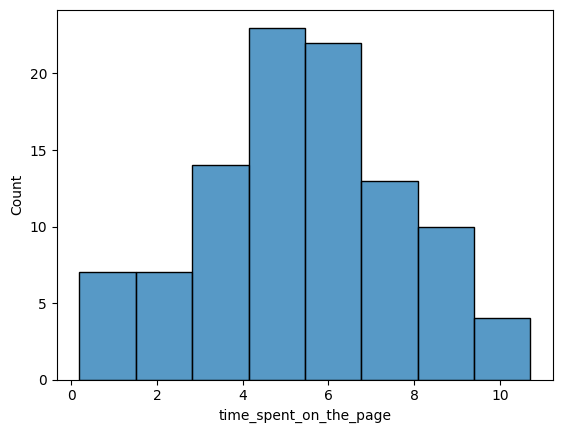

In [ ]:
hist1 = sns.histplot(ENews_data['time_spent_on_the_page'])

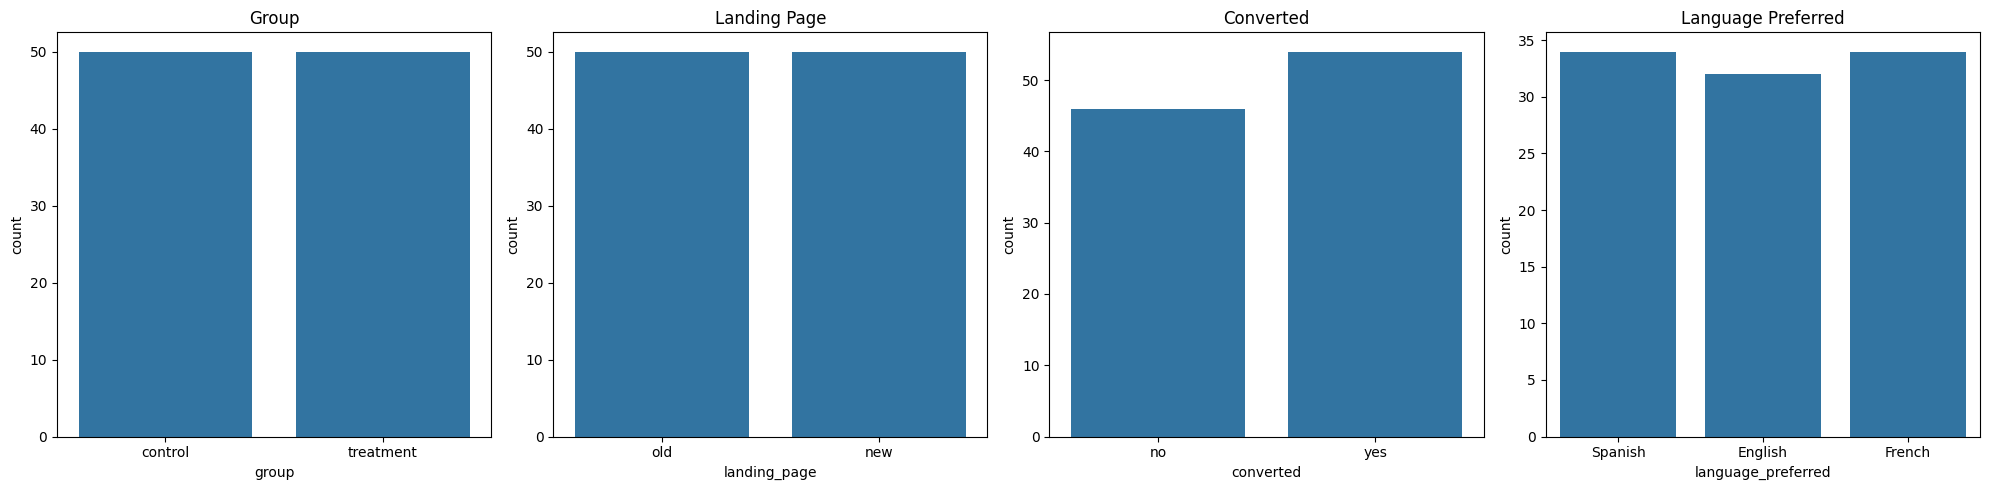

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
sns.countplot(x='group', data=ENews_data, ax=axes[0])
axes[0].set_title('Group')
sns.countplot(x='landing_page', data=ENews_data, ax=axes[1])
axes[1].set_title('Landing Page')
sns.countplot(x='converted', data=ENews_data, ax=axes[2])
axes[2].set_title('Converted')
sns.countplot(x='language_preferred', data=ENews_data, ax=axes[3])
axes[3].set_title('Language Preferred')
plt.tight_layout()
plt.show()



*   Already answered the questions for Univariate Analysis in the previous section. Repeating them below for accessibility:
    *   There are no missing values in the dataset.
    * There is one numerical variables: time_spent_on_the_page.
    * There are multiple categorical variables in the dataset:
      * Group, Landing_Page, and converted are all binary (only have two unique values).
        * Group and Landing_page both have the sample # of count (As Expected).
        * There is slight variation in count for "converted" (As Expected).
      * Language_preferred with 3 Uniques categorical values (Spanish, English, and French).
        * There is a slight variation in count for "language_preferred" (As Expected).
    * The Dataset has 100 data points.



### Bivariate Analysis

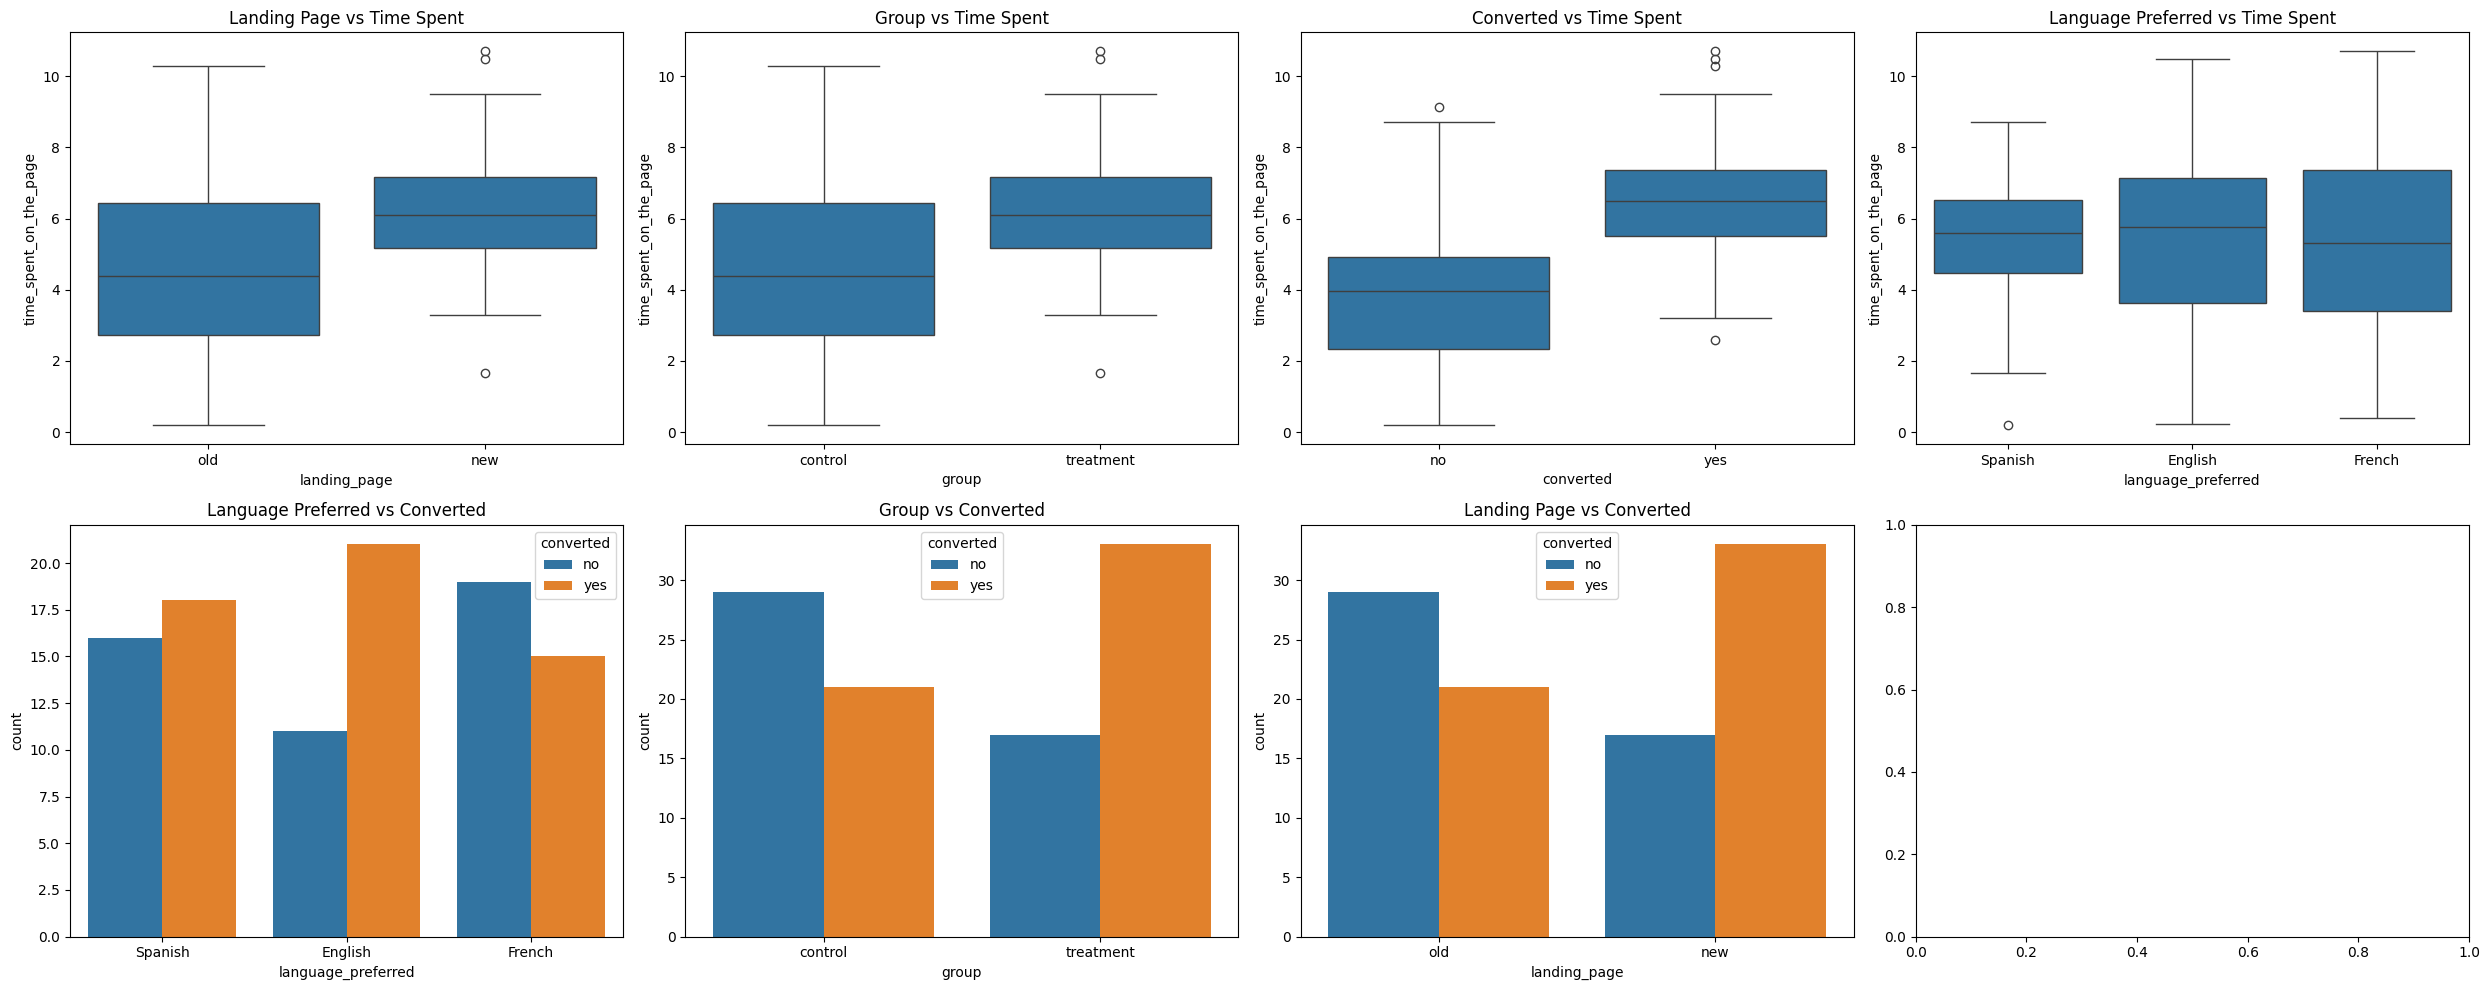

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(25,10))
sns.boxplot(data=ENews_data, x='landing_page', y='time_spent_on_the_page', ax=axes[0,0])
axes[0,0].set_title('Landing Page vs Time Spent')
sns.boxplot(data=ENews_data, x='group', y='time_spent_on_the_page', ax=axes[0,1])
axes[0,1].set_title('Group vs Time Spent')
sns.boxplot(data=ENews_data, x='converted', y='time_spent_on_the_page', ax=axes[0,2])
axes[0,2].set_title('Converted vs Time Spent')
sns.boxplot(data=ENews_data, x='language_preferred', y='time_spent_on_the_page', ax=axes[0,3])
axes[0,3].set_title('Language Preferred vs Time Spent')
sns.countplot(data=ENews_data, x='language_preferred', hue='converted', ax=axes[1,0])
axes[1,0].set_title('Language Preferred vs Converted')
sns.countplot(data=ENews_data, x='group', hue='converted', ax=axes[1,1])
axes[1,1].set_title('Group vs Converted')
sns.countplot(data=ENews_data, x='landing_page', hue='converted', ax=axes[1,2])
axes[1,2].set_title('Landing Page vs Converted')
plt.tight_layout()
plt.show()

* Some observations just from the visuals above:
  * The greatest variation (VISUALLY) seems to be with converted vs time spent.
    * More time spent shows correlation with convertion
  * Least variation is observed in the language_prefered vs time spent
    * All three languages seem (VISUALLY) to have spent a similar average time spent.
  * Looking at the countplot:
    * English has the highest converted count and the lowest non-converted count.
    * French is the only language with more non-converted counts than converted counts.

## 1. Do the users spend more time on the new landing page than the existing landing page?

### Perform Visual Analysis

Text(0.5, 1.0, 'Landing Page vs. Time Spent on Page')

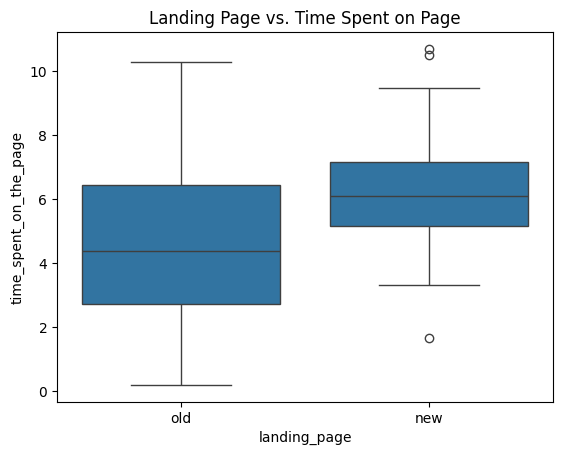

In [ ]:
plt1 = sns.boxplot(data=ENews_data,x='landing_page',y='time_spent_on_the_page')
plt1.set_title('Landing Page vs. Time Spent on Page')

### Step 1: Define the null and alternate hypotheses

H𝜊: μ(new) = μ(old)

H(alternative): μ(new) > μ(old)

### Step 2: Select Appropriate test

Since population std. dev is unknown and we are comparing the means of two independent variables, the appropriate test would be the "***2 Independent Samples T-Test***".

### Step 3: Decide the significance level

Significance Level has been determined in the objectives summary in the beginning of the notebook:
* ***Significance Level: 0.05 (5%)***.

### Step 4: Collect and prepare data

In [ ]:
print('The mean time spent on old landing page is ', ENews_data.groupby('landing_page')['time_spent_on_the_page'].mean()['old'])
print('The mean time spent on new landing page is ', ENews_data.groupby('landing_page')['time_spent_on_the_page'].mean()['new'])
print()
print('The standard deviation of time spent on old landing page is ', ENews_data.groupby('landing_page')['time_spent_on_the_page'].std()['old'])
print('The standard deviation of time spent on new landing page is ', ENews_data.groupby('landing_page')['time_spent_on_the_page'].std()['new'])

The mean time spent on old landing page is  4.5324
The mean time spent on new landing page is  6.2232

The standard deviation of time spent on old landing page is  2.581974849306046
The standard deviation of time spent on new landing page is  1.8170310387878268


The Assumptions for a 2-Independent Sample T-test hold true:
* Time Spent is continuous data.
* The Population Standard Deviations are NOT known for the two populations.
* The Standard Deviations are not equal for the two populations.
* It is normally distributed and is random sampling.

### Step 5: Calculate the p-value

In [ ]:
from scipy.stats import ttest_ind

old_time_spent = ENews_data[ENews_data['landing_page'] == 'old']['time_spent_on_the_page']
new_time_spent = ENews_data[ENews_data['landing_page'] == 'new']['time_spent_on_the_page']

test_stat, p_value = ttest_ind(new_time_spent, old_time_spent, equal_var = False, alternative = 'greater')
print('The p-value is ', p_value)

The p-value is  0.0001392381225166549


### Step 6: Compare the p-value with $\alpha$

In [ ]:
if p_value < 0.05:
  print('Reject the null hypothesis and conclude that the mean time spent on the new landing page is greater than that on the old landing page.')
else:
  print('Fail to reject the null hypothesis and conclude that the mean time spent on the new landing page is not greater than that on the old landing page.')

Reject the null hypothesis and conclude that the mean time spent on the new landing page is greater than that on the old landing page.


### Step 7:  Draw inference

Because out p_value for the 2 independent samples t-test came out to be ~0.00014, we can conclude that there **IS** significant evidence to state that users spent a greater amount of time on the new landing page compared to the old landing page.
* In other words, we reject the null hypothesis.

**A similar approach can be followed to answer the other questions.**

## 2. Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?

In [ ]:
#Calculating the convertion rate of new page
new_converted = ENews_data[ENews_data['landing_page'] == 'new']['converted'].value_counts()
print('The # of converted users for the new page is ', new_converted['yes'])
print('The # of non-converted users for the new page is ', new_converted['no'])
print('The total # of users who visited the new page is ', new_converted.sum())
print()
#Calculating the convertion rate of old page
old_converted = ENews_data[ENews_data['landing_page'] == 'old']['converted'].value_counts()
print('The # of converted users for the old page is ', old_converted['yes'])
print('The # of non-converted users for the old page is ', old_converted['no'])
print('The total # of users who visited the old page is ', old_converted.sum())

The # of converted users for the new page is  33
The # of non-converted users for the new page is  17
The total # of users who visited the new page is  50

The # of converted users for the old page is  21
The # of non-converted users for the old page is  29
The total # of users who visited the old page is  50


In [ ]:
#Testing if Z-test assumptions are satisfied
np_new = new_converted.sum() * (new_converted['yes'] / new_converted.sum())
print('np_new = ', np_new)
print('n(1-p)_new = ', new_converted.sum() - np_new)
print()
np_old = old_converted.sum() * (old_converted['yes'] / old_converted.sum())
print('np_old = ', np_old)
print('n(1-p)_old = ', old_converted.sum() - np_old)

np_new =  33.0
n(1-p)_new =  17.0

np_old =  21.0
n(1-p)_old =  29.0


np and n(1-p) for both categories is greater than or equal to 10 so all assumptions are met for the 2-Sample Proportions Z-test.

***DEFINING NULL AND ALTERNATIVE HYPOTHESES:***

H𝜊: p(new) = p(old)

H(alternative): p(new) > p(old)

;where p = proportion

In [ ]:
from statsmodels.stats.proportion import proportions_ztest
z_value, p_value = proportions_ztest([new_converted['yes'], old_converted['yes']], [new_converted.sum(), old_converted.sum()], value = 0 , alternative = 'larger')
print('The p-value is ', p_value)

The p-value is  0.008026308204056278


In [ ]:
if p_value < 0.05:
  print('Reject the null hypothesis and conclude that the conversion rate for the new page is greater than that for the old page.')
else:
  print('Fail to reject the null hypothesis and conclude that the conversion rate for the new page is not greater than that for the old page.')

Reject the null hypothesis and conclude that the conversion rate for the new page is greater than that for the old page.


Because the p-value calculated from the 2-Sample Proportions Z-test is ~0.00803, we can conclude that there **IS** significant evidence to state that the convertion rate for the new landing page is greater than that for the old landing page.

## 3. Is the conversion and preferred language are independent or related?

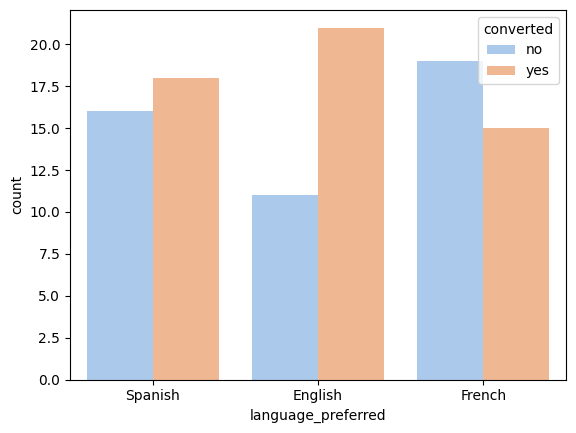

In [ ]:
plt2 = sns.countplot(data=ENews_data, x='language_preferred', hue='converted', palette='pastel')
plt2.figsize = (10, 5)

In [ ]:
English_converted = ENews_data[ENews_data['language_preferred'] == 'English']['converted'].value_counts()
print('The # of converted users for the English language is ', English_converted['yes'])
print('The # of non-converted users for the English language is ', English_converted['no'])
print('The total # of users who used the English language is ', English_converted.sum())
print()
French_converted = ENews_data[ENews_data['language_preferred'] == 'French']['converted'].value_counts()
print('The # of converted users for the French language is ', French_converted['yes'])
print('The # of non-converted users for the French language is ', French_converted['no'])
print('The total # of users who used the French language is ', French_converted.sum())
print()
Spanish_converted = ENews_data[ENews_data['language_preferred'] == 'Spanish']['converted'].value_counts()
print('The # of converted users for the Spanish language is ', Spanish_converted['yes'])
print('The # of non-converted users for the Spanish language is ', Spanish_converted['no'])
print('The total # of users who used the Spanish language is ', Spanish_converted.sum())

The # of converted users for the English language is  21
The # of non-converted users for the English language is  11
The total # of users who used the English language is  32

The # of converted users for the French language is  15
The # of non-converted users for the French language is  19
The total # of users who used the French language is  34

The # of converted users for the Spanish language is  18
The # of non-converted users for the Spanish language is  16
The total # of users who used the Spanish language is  34


***DEFINING NULL AND ALTERNATIVE HYPOTHESES:***

H𝜊: Convertion is independent of language preferred.

H(alternative): Convertion is not independent of language preferred.

In [ ]:
#Making a table
Contingency_Table = {
    'Language': ['English', 'French', 'Spanish'],
    'Converted': [English_converted['yes'], French_converted['yes'], Spanish_converted['yes']],
    'Non-Converted': [English_converted['no'], French_converted['no'], Spanish_converted['no']]
}
Chi_Data = pd.DataFrame(Contingency_Table)
Chi_Data

,Language,Converted,Non-Converted
0,English,21,11
1,French,15,19
2,Spanish,18,16


In [ ]:
from scipy.stats import chi2_contingency

# find the p-value
chi, p_value, dof, expected = chi2_contingency(Chi_Data.drop('Language', axis=1))
print('The p-value is', p_value)

The p-value is 0.2129888748754345


In [ ]:
if p_value < 0.05:
  print('Reject the null hypothesis and conclude that the conversion is not independent of language preferred.')
else:
  print('Fail to reject the null hypothesis and conclude that the conversion is independent of language preferred.')

Fail to reject the null hypothesis and conclude that the conversion is independent of language preferred.


Because the p-value for the Chi-Squared Test of Independence is ~0.213, we do NOT have significant evidence to reject the null hypothesis and conclude that convertion is independent of language preferred.

## 4. Is the time spent on the new page same for the different language users?

In [ ]:
New_Page_Data = ENews_data[ENews_data['landing_page'] == 'new']
New_Page_Data.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
4,546459,treatment,new,4.75,yes,Spanish
6,546448,treatment,new,5.25,yes,French
8,546461,treatment,new,10.71,yes,French


Text(0.5, 1.0, 'Language Preferred vs. Time Spent on New Page')

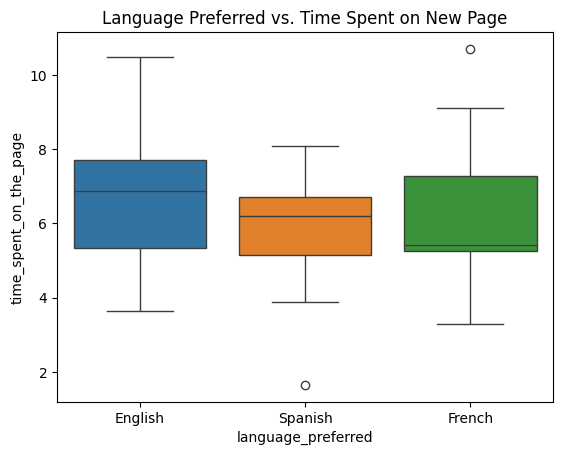

In [ ]:
plt3 = sns.boxplot(data=New_Page_Data,x='language_preferred',y='time_spent_on_the_page', hue = 'language_preferred')
plt3.set_title('Language Preferred vs. Time Spent on New Page')

In [ ]:
New_Page_Data.groupby('language_preferred')['time_spent_on_the_page'].mean()

,time_spent_on_the_page
language_preferred,
English,6.663750
French,6.196471
Spanish,5.835294


***DEFINING NULL AND ALTERNATIVE HYPOTHESES:***

H𝜊: μ(English) = μ(Spanish) = μ(French)

H(alternative): At least one of these mean time spent is different from the others.

### Shapiro-Wilk’s test

Null hypothesis

>$H_0:$ Time Spent on New page follows a normal distribution

Alternative hypothesis

>$H_a:$ Time Spent on New page does not follow a normal distribution

In [ ]:
# Assumption 1: Normality
# find the p-value
w, p_value = stats.shapiro(New_Page_Data['time_spent_on_the_page'])
print('The p-value is', p_value)

The p-value is 0.8040040364746845


Since p-value of the test is very large, we fail to reject the null hypothesis that the time spent on new page follows the normal distribution.

### Levene’s test

Null hypothesis

>$H_0$: All the population variances are equal

Alternative hypothesis

>$H_a$: At least one variance is different from the rest

In [ ]:
#Assumption 2: Homogeneity of Variance
from scipy.stats import levene
statistic, p_value = levene(New_Page_Data['time_spent_on_the_page'][New_Page_Data['language_preferred'] == 'English'],
                            New_Page_Data['time_spent_on_the_page'][New_Page_Data['language_preferred'] == 'Spanish'],
                            New_Page_Data['time_spent_on_the_page'][New_Page_Data['language_preferred'] == 'French'])
# find the p-value
print('The p-value is', p_value)

The p-value is 0.46711357711340173


Since the p-value is large, we fail to reject the null hypothesis of homogeneity of variances.

## ANOVA Test

In [ ]:
#import the required function
from scipy.stats import f_oneway

# perform one-way anova test
test_stat, p_value = f_oneway(New_Page_Data.loc[New_Page_Data['language_preferred'] == 'English', 'time_spent_on_the_page'],
                               New_Page_Data.loc[New_Page_Data['language_preferred'] == 'Spanish', 'time_spent_on_the_page'],
                               New_Page_Data.loc[New_Page_Data['language_preferred'] == 'French', 'time_spent_on_the_page'])
print('The p-value is ' + str(p_value))

The p-value is 0.43204138694325955


Since the p-value from the One-Way ANOVA test is ~0.432, we do NOT have significant evidence to reject the null hypothesis. It can be concluded that time spent on new page for different language users is the same.

## Conclusion and Business Recommendations

From the above statistical tests, there are a few inferences we can make about the new landing page versus the old langing page:
* The Business objective to increase engagement on their website through the new landing page can be deemed successful due to there being significant evidence that users spend more time on the new landing pages than the old one.

* The Business also wanted to see if the new landing page is successful in converting users. The proportions z-test proved that there is enough significant evidence to conclude that more proportion of users convert from the new landing page than the old landing page.

* Through the chi-squre test of independence and the one-way ANOVA test, it is concluded that preferred language does **NOT** play a significant role in conversions or time spent on page.

*In conclusion, the new landing page is significantly successful in gathering new subscribers compared to the old landing page.*